# 02 - LR Baseline Current Stress

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import importlib.util
import json
import joblib

import mlflow
import mlflow.sklearn
import pandas as pd
from mlflow.models import infer_signature
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

CANDIDATE_DIRS = [
    Path.cwd(),
    Path.cwd() / "nostressia-machine-learning" / "Current-Stress" / "notebooks" / "experiments",
]
UTILS_PATH = next((d / "mlflow_utils.py" for d in CANDIDATE_DIRS if (d / "mlflow_utils.py").exists()), None)
if UTILS_PATH is None:
    raise FileNotFoundError("mlflow_utils.py tidak ditemukan. Pastikan notebook dijalankan dari root repo atau folder experiments.")

spec = importlib.util.spec_from_file_location("cs_mlflow_utils", UTILS_PATH)
cs_utils = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(cs_utils)

RANDOM_STATE = cs_utils.RANDOM_STATE
configure_mlflow = cs_utils.configure_mlflow
set_seeds = cs_utils.set_seeds
load_current_stress_dataset = cs_utils.load_current_stress_dataset
get_dataset_path = cs_utils.get_dataset_path
select_feature_set = cs_utils.select_feature_set
split_data = cs_utils.split_data
build_preprocessor = cs_utils.build_preprocessor
evaluate_classification = cs_utils.evaluate_classification
measure_latency_percentiles = cs_utils.measure_latency_percentiles
log_classification_artifacts = cs_utils.log_classification_artifacts
log_run_metadata = cs_utils.log_run_metadata
create_local_output_dir = cs_utils.create_local_output_dir

repo_root = configure_mlflow()
set_seeds(RANDOM_STATE)


[local-result] Saved artifacts directory: D:\projects\nostressia\nostressia-machine-learning\Current-Stress\notebooks\experiments\local_results\02_lr_baseline_current_stress\49c381fca21f4390941432b993a3879e
[ipynb-result] Output folder: D:\projects\nostressia\nostressia-machine-learning\Current-Stress\notebooks\experiments\local_results\02_lr_baseline_current_stress\49c381fca21f4390941432b993a3879e
[ipynb-result] Saved files:
- metrics.json
- model.joblib
- test_classification_report.json
- test_classification_report.txt
- test_confusion_matrix.png
- test_predictions.csv
- test_probabilities.csv

[ipynb-result] Classification report:

              precision    recall  f1-score   support

           0     0.8548    0.8983    0.8760        59
           1     0.8254    0.7704    0.7969       135
           2     0.8679    0.8932    0.8804       206

    accuracy                         0.8525       400
   macro avg     0.8494    0.8540    0.8511       400
weighted avg     0.8516    0.85

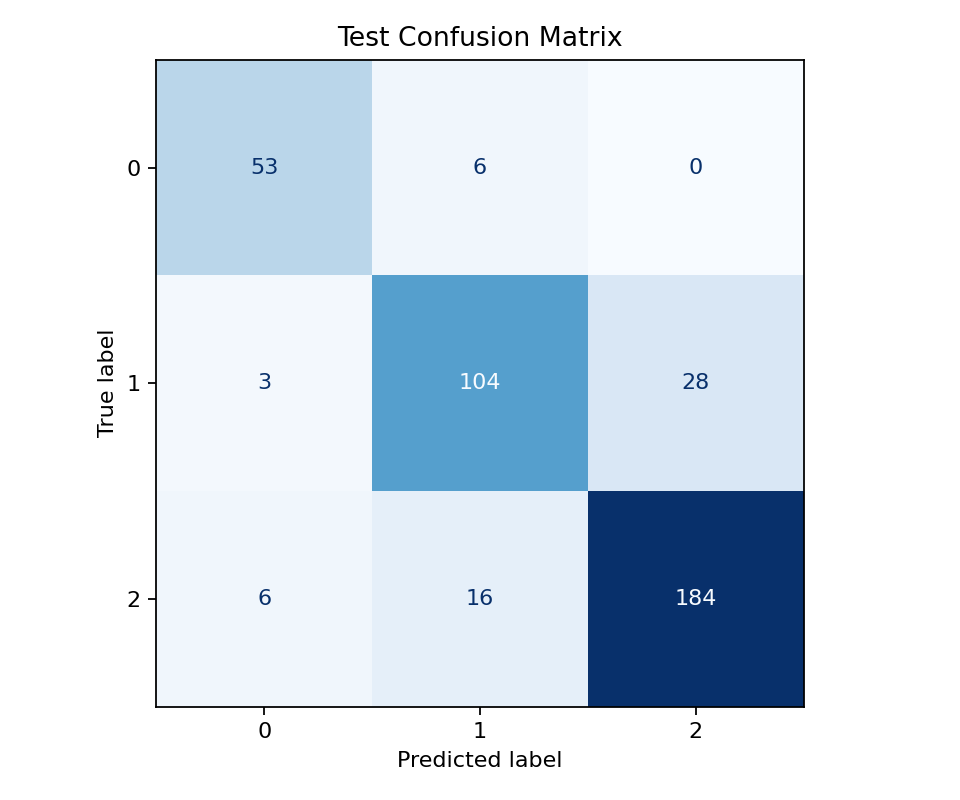

2026/02/21 23:24:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID: 49c381fca21f4390941432b993a3879e
Local output: D:\projects\nostressia\nostressia-machine-learning\Current-Stress\notebooks\experiments\local_results\02_lr_baseline_current_stress\49c381fca21f4390941432b993a3879e
Registered model: CurrentStress
accuracy                         0.852500
balanced_accuracy                0.853960
confidence_p50                   0.846055
confidence_p90                   0.991682
confidence_p95                   0.997372
confidence_p99                   0.999502
f1_macro                         0.851117
f1_weighted                      0.851578
latency_predict_p50_ms           2.608100
latency_predict_p90_ms           4.537430
latency_predict_p95_ms           5.753990
latency_predict_p99_ms          19.488095
latency_predict_proba_p50_ms     2.548500
latency_predict_proba_p90_ms     3.757460
latency_predict_proba_p95_ms     4.280475
latency_predict_proba_p99_ms     5.148564
log_loss                         0.357312
mcc                              0

Successfully registered model 'CurrentStress'.
Created version '1' of model 'CurrentStress'.


In [2]:
from IPython.display import Image, display
NOTEBOOK_NAME = "02_lr_baseline_current_stress.ipynb"
RUN_NAME = "LR Baseline - Current Stress"
FEATURE_SET = "all"
REGISTERED_MODEL_NAME = "CurrentStress"

raw_df, feature_df, y = load_current_stress_dataset(repo_root)
dataset_source = str(get_dataset_path(repo_root))
X = select_feature_set(feature_df, FEATURE_SET)
X_train, X_test, y_train, y_test = split_data(X, y)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()
preprocessor = build_preprocessor(num_cols, cat_cols)

model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))])

with mlflow.start_run(run_name=RUN_NAME) as run:
    dataset_payload = pd.concat([
        X_train.assign(target=y_train.values, split_set="train"),
        X_test.assign(target=y_test.values, split_set="test"),
    ], ignore_index=True)

    log_run_metadata(
        run_description="LR Baseline - Current Stress; features=all; dataset=current_stress_v1; split=80/20; random_state=42; baseline LR",
        tags={"features": FEATURE_SET, "model": RUN_NAME},
        params={"registered_model_name": REGISTERED_MODEL_NAME, **{"model_type":"LogisticRegression"}},
        dataset_df=dataset_payload,
        dataset_context="training",
        dataset_source=dataset_source,
    )

    
    model.fit(X_train, y_train)
    

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    metrics = evaluate_classification(y_test, y_pred, y_proba)
    mlflow.log_metrics(metrics)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    metrics = evaluate_classification(y_test, y_pred, y_proba)
    latency_metrics = measure_latency_percentiles(model, X_test, include_predict_proba=y_proba is not None)
    metrics.update(latency_metrics)
    mlflow.log_metrics(metrics)

    local_output_dir = create_local_output_dir(repo_root, NOTEBOOK_NAME, run.info.run_id)
    print(f"[ipynb-result] Output folder: {local_output_dir}")
    log_classification_artifacts(y_test, y_pred, local_output_dir, y_proba, prefix="test")
    (local_output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    joblib.dump(model, local_output_dir / "model.joblib")

    mlflow.log_artifacts(str(local_output_dir), artifact_path="local_outputs")
    print("[ipynb-result] Saved files:")
    for saved_file in sorted(local_output_dir.glob("*")):
        print("-", saved_file.name)
    report_path = local_output_dir / "test_classification_report.txt"
    if report_path.exists():
        print("\n[ipynb-result] Classification report:\n")
        print(report_path.read_text(encoding="utf-8"))
    display(Image(filename=str(local_output_dir / "test_confusion_matrix.png")))

    signature = infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_train.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

    print("Run ID:", run.info.run_id)
    print("Local output:", local_output_dir)
    print("Registered model:", REGISTERED_MODEL_NAME)
    print(pd.Series(metrics).sort_index())
